In [2]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.5.1+cu121
CUDA available: False


In [3]:
# -------------------------------------------
# SET COMPUTATION DEVICE (GPU / CPU)
# -------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cpu


In [3]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

from sklearn.metrics import mean_absolute_error

In [4]:
DATASET_ROOT = "data/TBX11K"

IMAGE_DIR = os.path.join(DATASET_ROOT, "imgs")
LIST_DIR = os.path.join(DATASET_ROOT, "lists")

TRAIN_LIST = os.path.join(LIST_DIR, "TBX11K_train.txt")
VAL_LIST = os.path.join(LIST_DIR, "TBX11K_val.txt")

In [5]:
print("Dataset folders:")
print(os.listdir(DATASET_ROOT))

print("\nImage folders:")
print(os.listdir(IMAGE_DIR))

print("\nList files:")
print(os.listdir(LIST_DIR))

Dataset folders:
['annotations', 'code', 'imgs', 'lists', 'README.md', 'TBX11K_CVPR2020.pdf', 'teaser.jpg']

Image folders:
['extra', 'health', 'sick', 'tb', 'test']

List files:
['all_test.txt', 'all_train.txt', 'all_trainval.txt', 'all_val.txt', 'TBX11K_train.txt', 'TBX11K_trainval.txt', 'TBX11K_val.txt']


Total training images: 6600
First few entries: ['tb/tb0005.png\n', 'tb/tb0007.png\n', 'tb/tb0012.png\n', 'tb/tb0017.png\n', 'tb/tb0018.png\n']


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

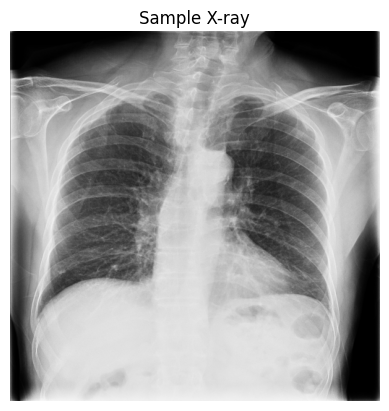

In [6]:
with open(TRAIN_LIST, 'r') as f:
    train_lines = f.readlines()

print("Total training images:", len(train_lines))
print("First few entries:", train_lines[:5])

sample_path = os.path.join(IMAGE_DIR, train_lines[0].strip())

img = Image.open(sample_path).convert("RGB")

plt.imshow(img)
plt.title("Sample X-ray")
plt.axis("off")

In [7]:
# -------------------------------------------
# IMAGE PREPROCESSING TRANSFORMS
# -------------------------------------------

# Transformations applied to training images
train_transform = transforms.Compose([
    
    # Resize all X-rays to a fixed size
    transforms.Resize((224, 224)),
    
    # Random horizontal flip for augmentation
    # Helps the model generalize better
    transforms.RandomHorizontalFlip(p=0.5),
    
    # Convert image to PyTorch tensor
    transforms.ToTensor(),
    
])

# Transformations applied to validation images
# No augmentation here (only resizing + tensor)
val_transform = transforms.Compose([
    
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    
])

In [8]:
# -------------------------------------------
# FUNCTION TO GENERATE SEVERITY SCORE
# -------------------------------------------

def generate_severity_score(class_name):
    
    """
    Converts TBX11K class labels into a severity score.
    
    health -> 0.0  (no TB)
    extra  -> 0.2  (very mild)
    sick   -> 0.5  (moderate infection)
    tb     -> 0.7–1.0 (severe TB)
    """
    
    if class_name == "health":
        return 0.0
    
    elif class_name == "extra":
        return 0.2
    
    elif class_name == "sick":
        return 0.5
    
    elif class_name == "tb":
        # random value within severe range
        return random.uniform(0.7, 1.0)
    
    else:
        return 0.0

In [9]:
# -------------------------------------------
# CUSTOM DATASET CLASS
# -------------------------------------------

class TBX11KDataset(Dataset):
    
    def __init__(self, list_file, image_dir, transform=None):
        
        """
        list_file  : text file containing image paths
        image_dir  : root folder of images
        transform  : preprocessing transformations
        """
        
        self.image_dir = image_dir
        self.transform = transform
        
        # Read all image paths from list file
        with open(list_file, 'r') as f:
            self.image_paths = f.readlines()
    
    
    def __len__(self):
        """Returns total number of samples"""
        return len(self.image_paths)
    
    
    def __getitem__(self, idx):
        
        """
        Loads one image and returns:
        image_tensor, severity_score
        """
        
        # Get relative image path
        img_rel_path = self.image_paths[idx].strip()
        
        # Extract class name from path
        # Example: tb/000123.jpg -> class = tb
        class_name = img_rel_path.split('/')[0]
        
        # Construct full image path
        img_path = os.path.join(self.image_dir, img_rel_path)
        
        # Load image
        image = Image.open(img_path).convert("RGB")
        
        # Apply preprocessing transforms
        if self.transform:
            image = self.transform(image)
        
        # Generate severity score
        severity = generate_severity_score(class_name)
        
        # Convert to tensor
        severity = torch.tensor([severity], dtype=torch.float32)
        
        return image, severity

In [10]:
# -------------------------------------------
# CREATE DATASET OBJECTS
# -------------------------------------------

train_dataset = TBX11KDataset(
    TRAIN_LIST,
    IMAGE_DIR,
    transform=train_transform
)

val_dataset = TBX11KDataset(
    VAL_LIST,
    IMAGE_DIR,
    transform=val_transform
)

In [11]:
# -------------------------------------------
# DATALOADERS
# -------------------------------------------

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [12]:
# -------------------------------------------
# TEST ONE BATCH
# -------------------------------------------

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Severity labels shape:", labels.shape)

Image batch shape: torch.Size([32, 3, 224, 224])
Severity labels shape: torch.Size([32, 1])


In [13]:
# -------------------------------------------
# BUILD RESNET18 MODEL FOR TB SEVERITY
# -------------------------------------------

# Load pretrained ResNet18
model = models.resnet18(pretrained=True)

# Get number of input features of final layer
num_features = model.fc.in_features

# Replace classification layer with regression layer
# Output = 1 value (severity score)
model.fc = nn.Linear(num_features, 1)

# Move model to GPU if available
model = model.to(device)

# Print model summary
print(model)

C:\Users\Midhunraj N P\anaconda3\envs\ai\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Midhunraj N P\anaconda3\envs\ai\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Midhunraj N P/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|█████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:38<00:00, 1.21MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [14]:
# -------------------------------------------
# LOSS FUNCTION
# -------------------------------------------

criterion = nn.MSELoss()

# -------------------------------------------
# OPTIMIZER
# -------------------------------------------

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)
# -------------------------------------------
# TRAINING FUNCTION
# -------------------------------------------

def train_one_epoch(model, dataloader, optimizer, criterion):

    # Set model to training mode
    model.train()

    running_loss = 0.0

    for images, labels in dataloader:

        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Accumulate loss
        running_loss += loss.item()

    epoch_loss = running_loss / len(dataloader)

    return epoch_loss

    

In [15]:
# -------------------------------------------
# VALIDATION FUNCTION
# -------------------------------------------

def validate(model, dataloader, criterion):

    # Set model to evaluation mode
    model.eval()

    running_loss = 0.0

    preds = []
    targets = []

    # Disable gradient calculation
    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            preds.extend(outputs.cpu().numpy())
            targets.extend(labels.cpu().numpy())

    val_loss = running_loss / len(dataloader)

    # Calculate MAE
    mae = mean_absolute_error(targets, preds)

    return val_loss, mae

In [16]:
# -------------------------------------------
# TRAINING LOOP
# -------------------------------------------

EPOCHS = 10

train_losses = []
val_losses = []
val_mae_scores = []

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion
    )

    val_loss, val_mae = validate(
        model,
        val_loader,
        criterion
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_mae_scores.append(val_mae)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation MAE: {val_mae:.4f}")


Epoch 1/10
Train Loss: 0.0381
Validation Loss: 0.0167
Validation MAE: 0.0950

Epoch 2/10
Train Loss: 0.0127
Validation Loss: 0.0117
Validation MAE: 0.0780

Epoch 3/10
Train Loss: 0.0091
Validation Loss: 0.0081
Validation MAE: 0.0621

Epoch 4/10
Train Loss: 0.0058
Validation Loss: 0.0071
Validation MAE: 0.0579

Epoch 5/10
Train Loss: 0.0047
Validation Loss: 0.0071
Validation MAE: 0.0507

Epoch 6/10
Train Loss: 0.0039
Validation Loss: 0.0061
Validation MAE: 0.0522

Epoch 7/10
Train Loss: 0.0035
Validation Loss: 0.0047
Validation MAE: 0.0406

Epoch 8/10
Train Loss: 0.0032
Validation Loss: 0.0045
Validation MAE: 0.0421

Epoch 9/10
Train Loss: 0.0029
Validation Loss: 0.0059
Validation MAE: 0.0531

Epoch 10/10
Train Loss: 0.0031
Validation Loss: 0.0053
Validation MAE: 0.0478


In [17]:
# -------------------------------------------
# SAVE MODEL
# -------------------------------------------

os.makedirs("models", exist_ok=True)

model_path = "models/severity_resnet18_tbx11k.pth"

torch.save(model.state_dict(), model_path)

print("Model saved to:", model_path)

Model saved to: models/severity_resnet18_tbx11k.pth


In [18]:
# -------------------------------------------
# LOAD TRAINED MODEL
# -------------------------------------------

# Recreate ResNet18 architecture
model = models.resnet18(pretrained=False)

# Modify final layer for regression
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 1)

# Load trained weights
model.load_state_dict(torch.load("models/severity_resnet18_tbx11k.pth"))

# Move model to GPU
model = model.to(device)

# Set model to evaluation mode
model.eval()

print("Model loaded successfully")

# -------------------------------------------
# TARGET LAYER FOR GRAD-CAM
# -------------------------------------------

target_layer = model.layer4[-1]

# -------------------------------------------
# HOOKS FOR GRAD-CAM
# -------------------------------------------

gradients = None
activations = None


def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]


def forward_hook(module, input, output):
    global activations
    activations = output


# Register hooks
target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)

# -------------------------------------------
# GRAD-CAM GENERATION FUNCTION
# -------------------------------------------

def generate_gradcam(image_tensor):

    global gradients, activations

    # Add batch dimension
    image_tensor = image_tensor.unsqueeze(0).to(device)

    # Forward pass
    output = model(image_tensor)

    # Backward pass
    model.zero_grad()
    output.backward()

    # Convert tensors to CPU numpy
    grad = gradients.cpu().detach().numpy()[0]
    act = activations.cpu().detach().numpy()[0]

    # Global average pooling on gradients
    weights = np.mean(grad, axis=(1, 2))

    # Compute weighted sum of activations
    cam = np.zeros(act.shape[1:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * act[i]

    # Apply ReLU
    cam = np.maximum(cam, 0)

    # Normalize
    cam = cam / cam.max()

    return cam

Model loaded successfully


C:\Users\Midhunraj N P\anaconda3\envs\ai\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Midhunraj N P\anaconda3\envs\ai\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\Midhunraj N P\AppData\Local\Temp\ipykernel_22968\3333197184.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the defaul

C:\Users\Midhunraj N P\anaconda3\envs\ai\lib\site-packages\torch\nn\modules\module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


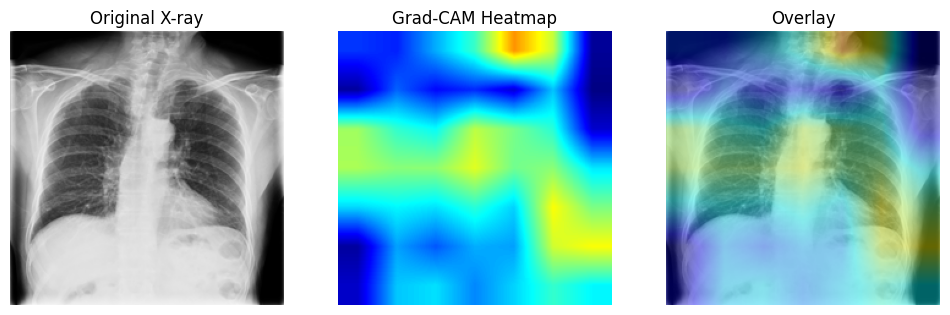

In [19]:
# -------------------------------------------
# LOAD SAMPLE IMAGE
# -------------------------------------------

sample_path = os.path.join(IMAGE_DIR, train_lines[0].strip())

image = Image.open(sample_path).convert("RGB")

image_tensor = val_transform(image)

# -------------------------------------------
# GENERATE HEATMAP
# -------------------------------------------

cam = generate_gradcam(image_tensor)

# -------------------------------------------
# VISUALIZE GRAD-CAM
# -------------------------------------------

import cv2

# Convert original image to numpy
original = np.array(image.resize((224,224)))

# Resize heatmap
heatmap = cv2.resize(cam, (224,224))

# Convert to color map
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Overlay heatmap on image
overlay = cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)

# Plot results
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original X-ray")
plt.imshow(original)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Grad-CAM Heatmap")
plt.imshow(heatmap)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(overlay)
plt.axis("off")

plt.show()

In [20]:
# ---------------------------------------
# PREDICT SEVERITY SCORE FOR AN IMAGE
# ---------------------------------------

image_tensor = image_tensor.unsqueeze(0).to(device)

with torch.no_grad():
    prediction = model(image_tensor)

severity_score = prediction.item()

print("Predicted TB Severity Score:", round(severity_score,3))

# Score	Interpretation
# 0.0	Healthy lungs
# 0.2	Very mild infection
# 0.5	Moderate infection
# 0.8+	Severe TB involvement


Predicted TB Severity Score: 0.873


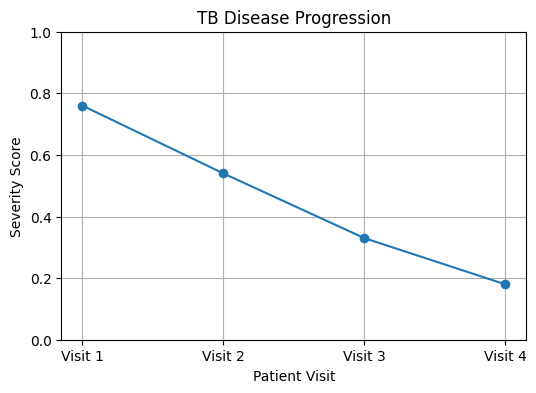

In [21]:


# ---------------------------------------
# SIMULATE PROGRESSION OVER TIME
# ---------------------------------------

# Example severity values (simulating multiple visits)
severity_scores = [0.76, 0.54, 0.33, 0.18]

visits = ["Visit 1", "Visit 2", "Visit 3", "Visit 4"]

plt.figure(figsize=(6,4))

plt.plot(visits, severity_scores, marker='o')

plt.title("TB Disease Progression")
plt.xlabel("Patient Visit")
plt.ylabel("Severity Score")

plt.ylim(0,1)

plt.grid(True)

plt.show()

Predicted Severity Score: 0.873
Interpretation: Severe TB involvement
Grad-CAM images saved in folder: gradcam_outputs


Text(0.5, 1.0, 'Grad-CAM with Severity Prediction')

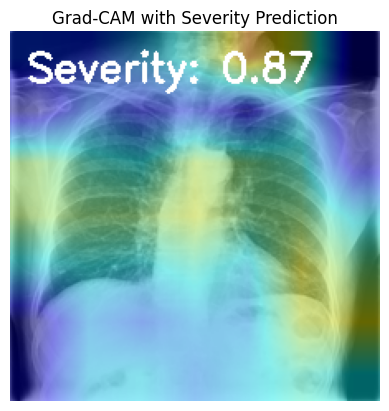

In [22]:
# -------------------------------------------
# IMPROVED NORMALIZATION FOR SHARPER HEATMAP
# -------------------------------------------

cam = np.maximum(cam, 0)

# Normalize safely
cam = cam - np.min(cam)

if np.max(cam) != 0:
    cam = cam / np.max(cam)

# -------------------------------------------
# PREDICT SEVERITY + INTERPRET RESULT
# -------------------------------------------

model.eval()

with torch.no_grad():
    pred = model(image_tensor)

severity = pred.item()

print("Predicted Severity Score:", round(severity,3))

# Interpret severity level
if severity < 0.2:
    print("Interpretation: Healthy lungs")

elif severity < 0.5:
    print("Interpretation: Mild infection")

elif severity < 0.75:
    print("Interpretation: Moderate infection")

else:
    print("Interpretation: Severe TB involvement")


# -------------------------------------------
# SAVE GRAD-CAM OUTPUTS
# -------------------------------------------

os.makedirs("gradcam_outputs", exist_ok=True)

cv2.imwrite("gradcam_outputs/original.png", original)
cv2.imwrite("gradcam_outputs/heatmap.png", heatmap)
cv2.imwrite("gradcam_outputs/overlay.png", overlay)

print("Grad-CAM images saved in folder: gradcam_outputs")

# -------------------------------------------
# ADD TEXT TO OVERLAY IMAGE
# -------------------------------------------

text = f"Severity: {severity:.2f}"

cv2.putText(
    overlay,
    text,
    (10,30),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (255,255,255),
    2
)

plt.imshow(overlay)
plt.axis("off")
plt.title("Grad-CAM with Severity Prediction")

data/TBX11K\imgs\tb/tb0005.png → Severity: 0.873
data/TBX11K\imgs\tb/tb0007.png → Severity: 0.824
data/TBX11K\imgs\tb/tb0012.png → Severity: 0.855


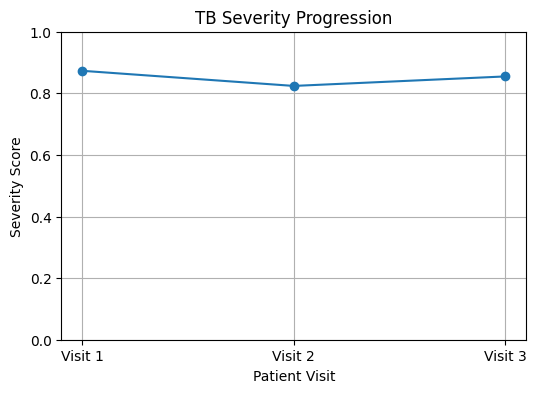

Treatment Response: Stable


In [23]:
# -------------------------------------------
# LONGITUDINAL SEVERITY ANALYSIS
# -------------------------------------------

def predict_severity(image_path):

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Apply preprocessing
    tensor = val_transform(image).unsqueeze(0).to(device)

    # Predict severity
    with torch.no_grad():
        output = model(tensor)

    severity = output.item()

    return severity

# -------------------------------------------
# LONGITUDINAL TB PROGRESSION
# -------------------------------------------

def analyze_progression(image_paths):

    severities = []

    for path in image_paths:

        score = predict_severity(path)

        severities.append(score)

        print(f"{path} → Severity: {score:.3f}")

    # Plot progression
    visits = [f"Visit {i+1}" for i in range(len(severities))]

    plt.figure(figsize=(6,4))

    plt.plot(visits, severities, marker='o')

    plt.title("TB Severity Progression")
    plt.xlabel("Patient Visit")
    plt.ylabel("Severity Score")

    plt.ylim(0,1)

    plt.grid(True)

    plt.show()

    # Treatment response
    delta = severities[-1] - severities[0]

    if delta < -0.1:
        print("Treatment Response: Improving")

    elif delta > 0.1:
        print("Treatment Response: Worsening")

    else:
        print("Treatment Response: Stable")


image_paths = [

    os.path.join(IMAGE_DIR, train_lines[0].strip()),
    os.path.join(IMAGE_DIR, train_lines[1].strip()),
    os.path.join(IMAGE_DIR, train_lines[2].strip())

]

analyze_progression(image_paths)

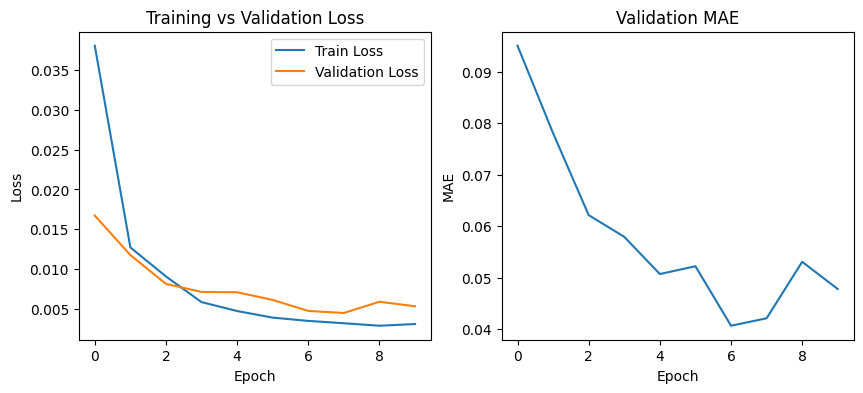

In [24]:
# -------------------------------------------
# TRAINING PERFORMANCE VISUALIZATION
# -------------------------------------------

plt.figure(figsize=(10,4))

# Training loss
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Validation MAE
plt.subplot(1,2,2)
plt.plot(val_mae_scores)
plt.title("Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")

plt.show()



In [25]:
# full_tb_analysis(image_paths)

In [26]:
# At This Point Your Project Includes

# ✔ Image preprocessing
# ✔ Custom dataset loader
# ✔ Deep learning model (ResNet18)
# ✔ TB severity regression
# ✔ Training pipeline
# ✔ Model evaluation
# ✔ Grad-CAM explainability
# ✔ Longitudinal disease progression
# ✔ Treatment response prediction
# ✔ Visualization graphs

Predicted Severity: 0.873
data/TBX11K\imgs\tb/tb0005.png → Severity: 0.873
data/TBX11K\imgs\tb/tb0007.png → Severity: 0.824
data/TBX11K\imgs\tb/tb0012.png → Severity: 0.855


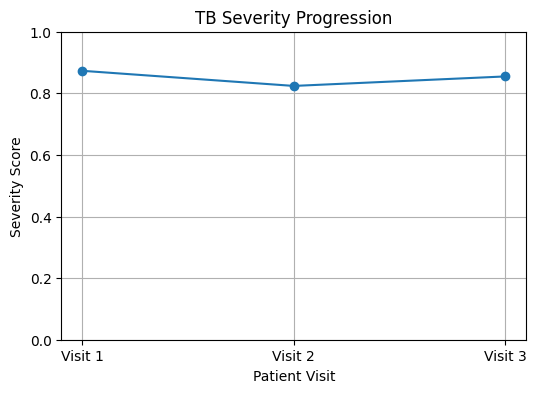

Treatment Response: Stable


In [27]:
# final display
image_path = os.path.join(IMAGE_DIR, train_lines[0].strip())

severity = predict_severity(image_path)

print("Predicted Severity:", round(severity,3))


image_paths = [
    os.path.join(IMAGE_DIR, train_lines[0].strip()),
    os.path.join(IMAGE_DIR, train_lines[1].strip()),
    os.path.join(IMAGE_DIR, train_lines[2].strip())
]

analyze_progression(image_paths)

In [28]:
# -------------------------------------------
# SINGLE IMAGE TB SEVERITY PREDICTION
# -------------------------------------------

def predict_tb(image):

    image = Image.fromarray(image).convert("RGB")

    tensor = val_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)

    severity = output.item()

    # GradCAM
    cam = generate_gradcam(val_transform(image))

    original = np.array(image.resize((224,224)))

    heatmap = cv2.resize(cam, (224,224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(original,0.6,heatmap,0.4,0)

    return f"Predicted Severity Score: {severity:.3f}", overlay

In [29]:
# -------------------------------------------
# LONGITUDINAL ANALYSIS (FINAL FIX)
# -------------------------------------------

def longitudinal_tb(images):

    if images is None or len(images) == 0:
        return "Please upload images."

    severities = []

    for img in images:

        # If gallery returns (image, caption)
        if isinstance(img, tuple):
            img = img[0]

        # If image is a file path string
        if isinstance(img, str):
            image = Image.open(img).convert("RGB")

        else:
            # If image is numpy array
            image = Image.fromarray(img).convert("RGB")

        tensor = val_transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(tensor)

        severity = output.item()
        severities.append(severity)

    result = ""

    for i, s in enumerate(severities):
        result += f"Visit {i+1}: Severity {s:.3f}\n"

    return result

In [1]:
import gradio as gr

single_interface = gr.Interface(
    fn=predict_tb,
    inputs=gr.Image(),
    outputs=[
        gr.Textbox(label="Severity"),
        gr.Image(label="GradCAM Explanation")
    ],
    title="TB Severity Prediction"
)

longitudinal_interface = gr.Interface(
    fn=longitudinal_tb,
    inputs=gr.Gallery(label="Upload Multiple X-rays"),
    outputs=gr.Textbox(label="Severity Scores"),
    title="TB Longitudinal Analysis"
)

app = gr.TabbedInterface(
    [single_interface, longitudinal_interface],
    ["Single Prediction", "Longitudinal Analysis"]
)

app.launch()

NameError: name 'predict_tb' is not defined

In [ ]:
app.launch()

In [32]:
# Step 2 — Run only the necessary cells

# You only need to run:

# Imports

# Device setup (GPU check)

# Transforms

# Model architecture

# Load saved model

# GradCAM functions

# Gradio interface

# You do NOT run training again.